# K05_01 – Logistische Regression mit Iris-Daten

Update am 24. Mai 2026

## Lernziele
- logistische Regression auf einen bekannten Datensatz anwenden
- Mehrklassenklassifikation in `scikit-learn` kennenlernen
- den Einfluss der Merkmalswahl auf die Modellgüte erkennen
- Accuracy und Konfusionsmatrix interpretieren

## 1. Bibliotheken importieren und Daten laden

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["species"] = [target_names[i] for i in y]

print(df.head())
print("\nShape von X:", X.shape)
print("Shape von y:", y.shape)
print("Klassen:", target_names)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Shape von X: (150, 4)
Shape von y: (150,)
Klassen: ['setosa' 'versicolor' 'virginica']


## 2. Zwei Merkmale visualisieren
Zur Übersicht betrachten wir zunächst zwei Merkmale:
- Petal length
- Petal width

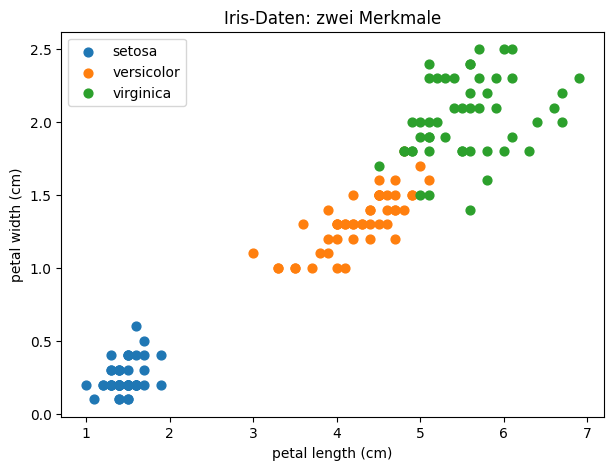

In [3]:
plt.figure(figsize=(7, 5))
for klasse, name in enumerate(target_names):
    plt.scatter(
        X[y == klasse, 2],
        X[y == klasse, 3],
        label=name,
        s=40
    )

plt.xlabel(feature_names[2])
plt.ylabel(feature_names[3])
plt.title("Iris-Daten: zwei Merkmale")
plt.legend()
plt.show()

## Exkurs: Mehrklassenklassifikation mit logistischer Regression

Iris hat **drei Klassen** (Setosa, Versicolor, Virginica).
Die logistische Regression ist ursprünglich für binäre Klassifikation (0 oder 1) konzipiert.

scikit-learn löst das automatisch mit der **One-vs-Rest-Strategie (OvR)**:

```
Modell 1: Setosa     vs. (Versicolor + Virginica)  -> P(Setosa)
Modell 2: Versicolor vs. (Setosa + Virginica)      -> P(Versicolor)
Modell 3: Virginica  vs. (Setosa + Versicolor)     -> P(Virginica)
```

Jedes Modell liefert eine Wahrscheinlichkeit. Die **Klasse mit der höchsten
Wahrscheinlichkeit gewinnt** -- aus drei binären Problemen wird ein
Mehrklassenproblem zusammengebaut.

```python
clf.predict_proba([[5.1, 3.5, 1.4, 0.2]])
# -> [[0.95, 0.04, 0.01]]  (Setosa, Versicolor, Virginica)
#       ^-- höchste Wahrscheinlichkeit -> Vorhersage: Setosa
```

> **Merksatz:** Bei k Klassen trainiert OvR intern k binäre Modelle.
> Die API bleibt identisch -- `fit()`, `predict()`, `predict_proba()` funktionieren
> genauso wie bei binärer Klassifikation.


## 3. Modell mit allen vier Merkmalen trainieren

Accuracy mit 4 Merkmalen: 0.933


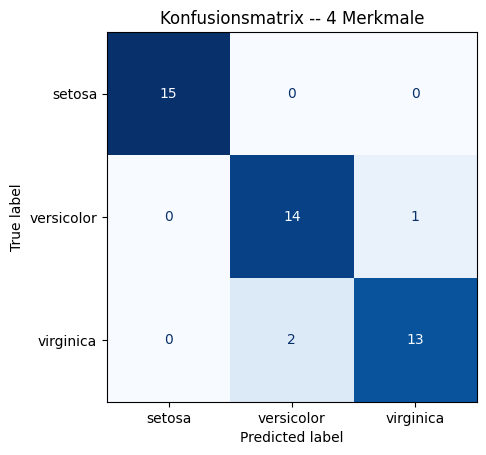

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
    # stratify=y: alle 3 Klassen gleichmäsig in Train und Test verteilen
)

clf_all = LogisticRegression(
    max_iter=300   # Standardwert 100 reicht hier nicht immer; 300 ist sicherer
)
clf_all.fit(X_train, y_train)

y_pred_all = clf_all.predict(X_test)
acc_all    = accuracy_score(y_test, y_pred_all)
cm_all     = confusion_matrix(y_test, y_pred_all)

print(f"Accuracy mit 4 Merkmalen: {acc_all:.3f}")

# Konfusionsmatrix mit Klassennamen beschriften
disp_all = ConfusionMatrixDisplay(
    confusion_matrix=cm_all,
    display_labels=target_names
)
disp_all.plot(cmap="Blues", colorbar=False, values_format="d")
plt.title("Konfusionsmatrix -- 4 Merkmale")
plt.show()


## 4. Modell nur mit zwei Merkmalen trainieren
Jetzt verwenden wir nur zwei Merkmale:
- Petal length
- Petal width

Accuracy mit 2 Merkmalen (Petal): 0.933


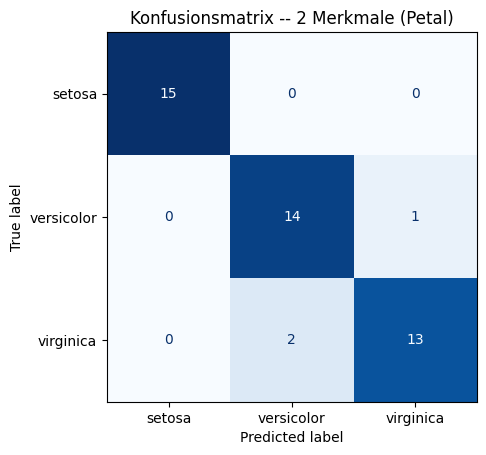

In [5]:
X_two = X[:, [2, 3]]   # petal length und petal width

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_two, y, test_size=0.3, random_state=42, stratify=y
)

clf_two = LogisticRegression(max_iter=300)
clf_two.fit(X_train2, y_train2)

y_pred_two = clf_two.predict(X_test2)
acc_two    = accuracy_score(y_test2, y_pred_two)
cm_two     = confusion_matrix(y_test2, y_pred_two)

print(f"Accuracy mit 2 Merkmalen (Petal): {acc_two:.3f}")

disp_two = ConfusionMatrixDisplay(
    confusion_matrix=cm_two,
    display_labels=target_names
)
disp_two.plot(cmap="Blues", colorbar=False, values_format="d")
plt.title("Konfusionsmatrix -- 2 Merkmale (Petal)")
plt.show()


## 5. Vergleich der Ergebnisse

In [6]:
print(f"Accuracy mit 4 Merkmalen: {acc_all:.3f}")
print(f"Accuracy mit 2 Merkmalen: {acc_two:.3f}")
print()
diff = acc_all - acc_two
if abs(diff) < 0.01:
    print("-> Kein Unterschied: die 2 Petal-Merkmale erklären Iris fast vollständig.")
elif diff > 0:
    print(f"-> 4 Merkmale sind um {diff:.3f} besser.")
else:
    print(f"-> 2 Merkmale sind hier sogar minimal besser ({abs(diff):.3f}).")
print()
print("Beobachtung: Petal-Merkmale (2+3) trennen Iris-Klassen sehr gut.")
print("Sepal-Merkmale (0+1) leisten weniger Beitrag.")


Accuracy mit 4 Merkmalen: 0.933
Accuracy mit 2 Merkmalen: 0.933

-> Kein Unterschied: die 2 Petal-Merkmale erklären Iris fast vollständig.

Beobachtung: Petal-Merkmale (2+3) trennen Iris-Klassen sehr gut.
Sepal-Merkmale (0+1) leisten weniger Beitrag.


## 6. Kleine Übung

**Aufgabe 1:**  
Vergleichen Sie die beiden Accuracy-Werte.

**Aufgabe 2:**  
Schreiben Sie in 2–3 Sätzen:
- Warum können 4 Merkmale besser sein als nur 2?
- Warum können trotzdem schon 2 gut gewählte Merkmale eine brauchbare Klassifikation ermöglichen?

## 6. Kleine Übung – Musterlösung

Accuracy mit Sepal-Merkmalen: 0.733


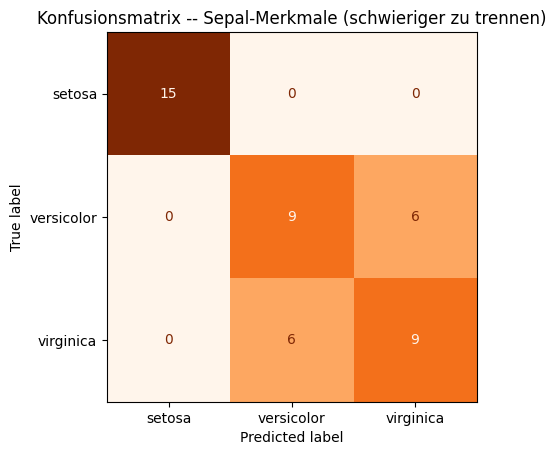

In [7]:
X_alt = X[:, [0, 1]]   # sepal length und sepal width

X_train_alt, X_test_alt, y_train_alt, y_test_alt = train_test_split(
    X_alt, y, test_size=0.3, random_state=42, stratify=y
)

clf_alt = LogisticRegression(
    max_iter=1000   # Sepal-Merkmale haben schlechtere Klassentrennung;
                    # der Optimierer braucht mehr Schritte zur Konvergenz
)
clf_alt.fit(X_train_alt, y_train_alt)
y_pred_alt = clf_alt.predict(X_test_alt)

acc_alt = accuracy_score(y_test_alt, y_pred_alt)
cm_alt  = confusion_matrix(y_test_alt, y_pred_alt)

print(f"Accuracy mit Sepal-Merkmalen: {acc_alt:.3f}")

disp_alt = ConfusionMatrixDisplay(
    confusion_matrix=cm_alt,
    display_labels=target_names
)
disp_alt.plot(cmap="Oranges", colorbar=False, values_format="d")
plt.title("Konfusionsmatrix -- Sepal-Merkmale (schwieriger zu trennen)")
plt.show()


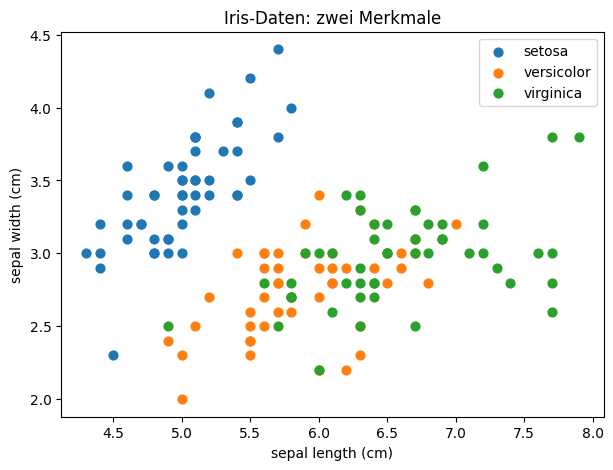

In [8]:
plt.figure(figsize=(7, 5))
for klasse, name in enumerate(target_names):
    plt.scatter(
        X[y == klasse, 0],
        X[y == klasse, 1],
        label=name,
        s=40
    )

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Iris-Daten: zwei Merkmale")
plt.legend()
plt.show()

### Musterantworten

**Warum können 4 Merkmale besser sein als nur 2?**  
Mehr Merkmale liefern dem Modell mehr Information zur Trennung der Klassen.

**Warum können 2 gut gewählte Merkmale trotzdem ausreichen?**  
Wenn diese Merkmale die Klassen bereits gut separieren, reicht die Information oft schon für gute Vorhersagen.

## Didaktischer Hinweis
Dieses Notebook ist ideal als Transfer vom einfachen binären Beispiel zu einem bekannten Mehrklassen-Datensatz.
Wichtig ist, den Fokus auf **Merkmalswahl und Modellgüte** zu legen, nicht auf zu viele Zusatzplots.

## 7. Reflexion
- Warum ist Iris hier ein Mehrklassenproblem?
- Welche Rolle spielt `max_iter`?
- Was zeigt die Konfusionsmatrix zusätzlich zur Accuracy?

## Reflexion – Erläuterung für Studierende

---

### Warum ist Iris ein Mehrklassenproblem?

Der Iris-Datensatz enthält **drei Klassen** (Setosa, Versicolor, Virginica). Die logistische Regression ist ursprünglich für binäre Klassifikation (0 oder 1) entworfen. Bei drei Klassen löst scikit-learn das automatisch mit der **„One-vs-Rest"-Strategie** (OvR):

```
Modell 1: Setosa     vs. (Versicolor + Virginica)
Modell 2: Versicolor vs. (Setosa + Virginica)
Modell 3: Virginica  vs. (Setosa + Versicolor)
```

Am Ende gewinnt die Klasse mit der höchsten Wahrscheinlichkeit. Aus drei binären Problemen wird also ein Mehrklassenproblem zusammengebaut.

---

### Welche Rolle spielt `max_iter`?

Die logistische Regression findet ihre Koeffizienten **nicht analytisch**, sondern durch einen iterativen Optimierungsalgorithmus (Gradientenabstieg). `max_iter` legt fest, wie viele Schritte dieser Algorithmus maximal machen darf:

```python
LogisticRegression(max_iter=200)  # Standard: 100
```

Ist der Wert zu klein, bricht das Training ab bevor die Lösung gefunden wurde — scikit-learn gibt dann eine `ConvergenceWarning` aus. Der Wert hat **keinen Einfluss auf die Modellqualität** selbst, nur darauf ob der Algorithmus genug Zeit hat, zu konvergieren. Bei gut skalierten Daten reichen meist 100–200 Iterationen.

---

### Was zeigt die Konfusionsmatrix zusätzlich zur Accuracy?

Die Accuracy sagt nur: *„X% aller Vorhersagen waren richtig."* Sie verbirgt, **wo** das Modell irrt. Die Konfusionsmatrix zeigt das vollständige Bild:

```
                  Vorhergesagt
                  Setosa  Versicolor  Virginica
Tatsächlich  Setosa     [  19,      0,          0  ]
             Versicolor [   0,     12,          1  ]
             Virginica  [   0,      2,         11  ]
```

Hier sieht man sofort: Das Modell verwechselt **Versicolor und Virginica** gelegentlich — Setosa erkennt es perfekt. Eine Accuracy von z. B. 93% würde das komplett verschweigen.

> **Merksatz:** Accuracy sagt *wie oft* das Modell richtig liegt. Die Konfusionsmatrix sagt *bei welchen Klassen* es daneben liegt — und das ist für die Praxis viel wertvoller.

## Abschluss: Finales Modell und Hinweis zur Skalierung

### Das finale Modell

Für den produktiven Einsatz trainieren wir das finale Modell auf allen Daten:


In [ ]:
# Finales Modell auf ALLEN Iris-Daten trainieren
clf_final = LogisticRegression(max_iter=300)
clf_final.fit(X, y)   # alle 150 Samples

print("Finales Modell (4 Merkmale) ist einsatzbereit.")

# Beispiel-Vorhersage
neuer_punkt = [[5.1, 3.5, 1.4, 0.2]]
klasse = clf_final.predict(neuer_punkt)[0]
proba  = clf_final.predict_proba(neuer_punkt)[0]

print(f"Vorhersage: {target_names[klasse]}")
print(f"Wahrscheinlichkeiten: "
      f"{dict(zip(target_names, proba.round(3)))}")

# Hinweis Skalierung
print()
print("Hinweis: Wir haben gelernt, Pipelines mit StandardScaler")
print("zu verwenden. Hier wurde aus Übersichtlichkeitsgründen darauf")
print("verzichtet. In der Praxis empfiehlt sich:")
print("  from sklearn.pipeline import make_pipeline")
print("  from sklearn.preprocessing import StandardScaler")
print("  clf_pipeline = make_pipeline(StandardScaler(), LogisticRegression())")
